In [34]:
import os
graphviz_path = r"c:\\Program Files\\Graphviz\bin"

# 将路径添加到系统的 PATH 环境变量中
os.environ["PATH"] += os.pathsep + graphviz_path

In [35]:

class Value:
    def __init__(self, data, children = (), _op="", label =""):
        self.data = data
        self._prev = set(children)
        self._op = _op
        self.label = label
        self.grad = 0.0
        
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self, rhs):
        return Value(self.data + rhs.data, (self, rhs), "+")
    def __mul__(self, rhs):
        return Value(self.data * rhs.data, (self, rhs), "*")
    def __truediv__(self, rhs):
        return Value(self.data / rhs.data, (self, rhs))
    def __floordiv__(self, rhs):
        return Value(self.data // rhs.data,(self, rhs))
    def __sub__(self, rhs):
        return Value(self.data - rhs.data, (self, rhs))
        

In [36]:
from graphviz import Digraph

def trace(root:Value):
    nodes, edges = set[Value](), set()
    def build(v:Value):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root:Value):
    dot = Digraph(format="svg", graph_attr={"rankdir":"LR"})
    nodes, edges = trace(root)
    for node in nodes:
        uid  = str(id(node))
        dot.node(name= uid, label=f"{node.label} | data {node.data:.4f} | grad {node.grad:.4f}", shape="record")
        if node._op:
            dot.node(name =  uid + node._op, label = node._op)
            dot.edge(uid + node._op, uid)
            
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+n2._op)
    return dot
    


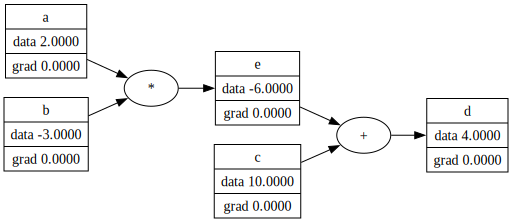

In [37]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0 , label="c")
d = a * b +c

d 
d._prev
d._op

e = a* b
e.label = "e"

d = e + c; d.label ="d"
draw_dot(d)

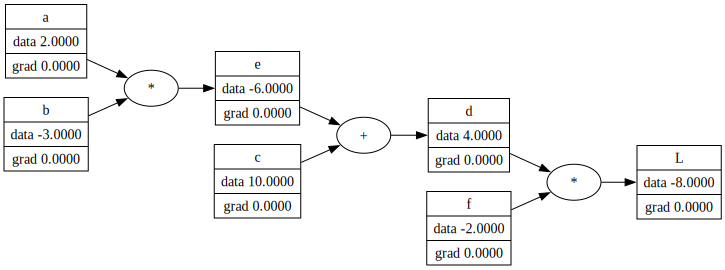

In [38]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0 , label="c")
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'

f = Value(-2.0, label="f")
L = d * f; L.label = 'L'
draw_dot(L)